In [2]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -------------- ------------------------- 2.9/8.2 MB 15.2 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.2 MB 14.2 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 14.0 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 12.7 MB/s eta 0:00:00

   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ------------------


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

from sklearn.experimental import enable_iterative_imputer  # required
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor


In [3]:
df = pd.read_csv(r"C:\Users\Karan\Downloads\real_estate_nj_sold.csv")

In [4]:
df

,type,text,listPrice,lastSoldPrice,sqft,stories,beds,baths,baths_full,garage,zip code,sold_to_list_ratio
0,single_family,"Welcome to [Redacted entity], a detached home ...",475000,504000,1586.0,2.0,1.0,3.0,2.0,2.0,7728.0,1.061053
1,single_family,Offer Accepted!!! No more showings! Fall in lo...,1049000,1125829,NaN,2.0,4.0,3.0,2.0,2.0,7748.0,1.073240
2,townhomes,The Amberley model showcases a chef's dream ki...,1399000,1350000,2783.0,NaN,3.0,4.0,2.0,2.0,7059.0,0.964975
3,single_family,"JCM Development delivers once again, seamlessl...",3795000,3700000,2945.0,3.0,5.0,5.0,5.0,NaN,8202.0,0.974967
4,single_family,"This well-maintained 2-bedroom, 1-bath ranch o...",349900,340000,768.0,NaN,2.0,1.0,1.0,NaN,8251.0,0.971706
...,...,...,...,...,...,...,...,...,...,...,...,...
7703,single_family,10 Room ''EXTRAVAGANZA'' AND an in-ground pool...,699900,680000,2331.0,2.0,4.0,3.0,2.0,1.0,8753.0,0.971567
7704,single_family,"Welcome to Woodbury! This charming 3-bedroom, ...",359900,375000,1320.0,3.0,3.0,2.0,1.0,NaN,8096.0,1.041956
7705,condos,"Welcome to this luxurious two-bedroom, two-bat...",570000,578000,1018.0,NaN,2.0,2.0,2.0,1.0,7087.0,1.014035
7706,single_family,Tucked away on a quiet cul-de-sac and surround...,925000,900000,NaN,NaN,4.0,4.0,3.0,3.0,8833.0,0.972973


In [1]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv(r"C:\Users\Karan\Downloads\real_estate_nj_sold.csv")


In [3]:
numeric_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

print("\nNumeric Columns:")
print(numeric_cols)


Numeric Columns:
Index(['listPrice', 'lastSoldPrice', 'sqft', 'stories', 'beds', 'baths',
       'baths_full', 'garage', 'zip code ', 'sold_to_list_ratio'],
      dtype='object')


In [4]:
imputer = IterativeImputer(
    estimator=RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    max_iter=10,
    random_state=42
)


In [5]:
df[numeric_cols] = imputer.fit_transform(
    df[numeric_cols]
)


In [6]:
categorical_cols = df.select_dtypes(
    include=['object']
).columns

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(
            df[col].mode()[0]
        )


In [7]:
print("\nMissing Values After Imputation:")
print(df.isnull().sum())



Missing Values After Imputation:
type                  0
text                  0
listPrice             0
lastSoldPrice         0
sqft                  0
stories               0
beds                  0
baths                 0
baths_full            0
garage                0
zip code              0
sold_to_list_ratio    0
dtype: int64


In [8]:
df.to_csv(
    "properties_imputed.csv",
    index=False
)

print("\nDataset Saved Successfully!")
print("Final Shape:", df.shape)



Dataset Saved Successfully!
Final Shape: (7708, 12)


In [9]:
print("\nFirst 5 Rows:")
print(df.head())


First 5 Rows:
            type                                               text  \
0  single_family  Welcome to [Redacted entity], a detached home ...   
1  single_family  Offer Accepted!!! No more showings! Fall in lo...   
2      townhomes  The Amberley model showcases a chef's dream ki...   
3  single_family  JCM Development delivers once again, seamlessl...   
4  single_family  This well-maintained 2-bedroom, 1-bath ranch o...   

   listPrice  lastSoldPrice     sqft  stories  beds  baths  baths_full  \
0   475000.0       504000.0  1586.00     2.00   1.0    3.0         2.0   
1  1049000.0      1125829.0  2723.32     2.00   4.0    3.0         2.0   
2  1399000.0      1350000.0  2783.00     3.20   3.0    4.0         2.0   
3  3795000.0      3700000.0  2945.00     3.00   5.0    5.0         5.0   
4   349900.0       340000.0   768.00     1.17   2.0    1.0         1.0   

   garage  zip code   sold_to_list_ratio  
0    2.00     7728.0            1.061053  
1    2.00     7748.0       

In [10]:
df

,type,text,listPrice,lastSoldPrice,sqft,stories,beds,baths,baths_full,garage,zip code,sold_to_list_ratio
0,single_family,"Welcome to [Redacted entity], a detached home ...",475000.0,504000.0,1586.00,2.00,1.0,3.0,2.0,2.00,7728.0,1.061053
1,single_family,Offer Accepted!!! No more showings! Fall in lo...,1049000.0,1125829.0,2723.32,2.00,4.0,3.0,2.0,2.00,7748.0,1.073240
2,townhomes,The Amberley model showcases a chef's dream ki...,1399000.0,1350000.0,2783.00,3.20,3.0,4.0,2.0,2.00,7059.0,0.964975
3,single_family,"JCM Development delivers once again, seamlessl...",3795000.0,3700000.0,2945.00,3.00,5.0,5.0,5.0,1.79,8202.0,0.974967
4,single_family,"This well-maintained 2-bedroom, 1-bath ranch o...",349900.0,340000.0,768.00,1.17,2.0,1.0,1.0,1.59,8251.0,0.971706
...,...,...,...,...,...,...,...,...,...,...,...,...
7703,single_family,10 Room ''EXTRAVAGANZA'' AND an in-ground pool...,699900.0,680000.0,2331.00,2.00,4.0,3.0,2.0,1.00,8753.0,0.971567
7704,single_family,"Welcome to Woodbury! This charming 3-bedroom, ...",359900.0,375000.0,1320.00,3.00,3.0,2.0,1.0,1.29,8096.0,1.041956
7705,condos,"Welcome to this luxurious two-bedroom, two-bat...",570000.0,578000.0,1018.00,1.44,2.0,2.0,2.0,1.00,7087.0,1.014035
7706,single_family,Tucked away on a quiet cul-de-sac and surround...,925000.0,900000.0,4134.57,2.15,4.0,4.0,3.0,3.00,8833.0,0.972973


In [12]:
df

,type,text,listPrice,lastSoldPrice,sqft,stories,beds,baths,baths_full,garage,zip code,sold_to_list_ratio
0,single_family,"Welcome to [Redacted entity], a detached home ...",475000.0,504000.0,1586.00,2.00,1.0,3.0,2.0,2.00,7728.0,1.061053
1,single_family,Offer Accepted!!! No more showings! Fall in lo...,1049000.0,1125829.0,2723.32,2.00,4.0,3.0,2.0,2.00,7748.0,1.073240
2,townhomes,The Amberley model showcases a chef's dream ki...,1399000.0,1350000.0,2783.00,3.20,3.0,4.0,2.0,2.00,7059.0,0.964975
3,single_family,"JCM Development delivers once again, seamlessl...",3795000.0,3700000.0,2945.00,3.00,5.0,5.0,5.0,1.79,8202.0,0.974967
4,single_family,"This well-maintained 2-bedroom, 1-bath ranch o...",349900.0,340000.0,768.00,1.17,2.0,1.0,1.0,1.59,8251.0,0.971706
...,...,...,...,...,...,...,...,...,...,...,...,...
7703,single_family,10 Room ''EXTRAVAGANZA'' AND an in-ground pool...,699900.0,680000.0,2331.00,2.00,4.0,3.0,2.0,1.00,8753.0,0.971567
7704,single_family,"Welcome to Woodbury! This charming 3-bedroom, ...",359900.0,375000.0,1320.00,3.00,3.0,2.0,1.0,1.29,8096.0,1.041956
7705,condos,"Welcome to this luxurious two-bedroom, two-bat...",570000.0,578000.0,1018.00,1.44,2.0,2.0,2.0,1.00,7087.0,1.014035
7706,single_family,Tucked away on a quiet cul-de-sac and surround...,925000.0,900000.0,4134.57,2.15,4.0,4.0,3.0,3.00,8833.0,0.972973


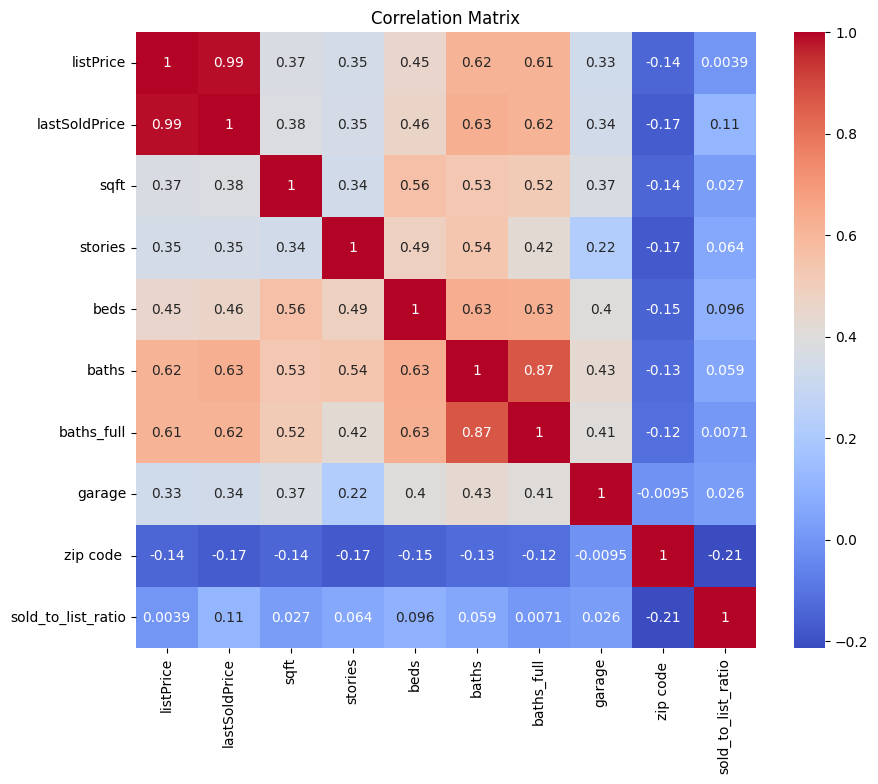

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

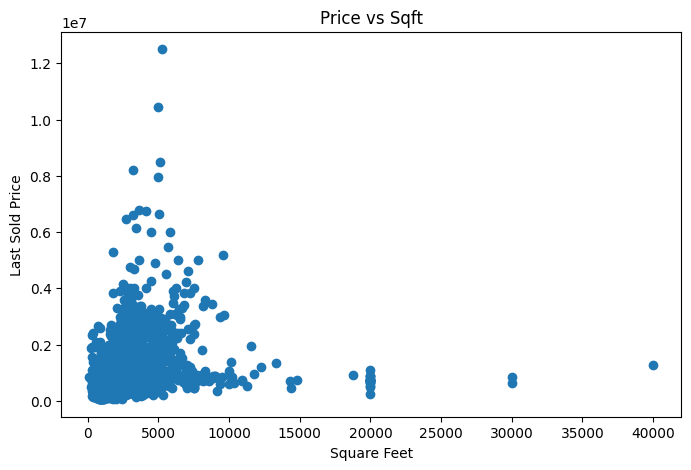

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(df['sqft'], df['lastSoldPrice'])
plt.xlabel('Square Feet')
plt.ylabel('Last Sold Price')
plt.title('Price vs Sqft')
plt.show()

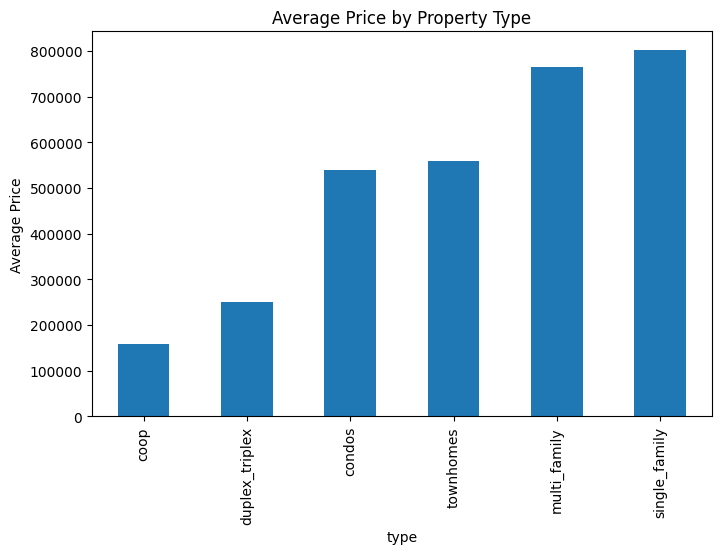

In [21]:
avg_price = df.groupby('type')['lastSoldPrice'].mean().sort_values()

avg_price.plot(kind='bar', figsize=(8,5))
plt.title('Average Price by Property Type')
plt.ylabel('Average Price')
plt.show()

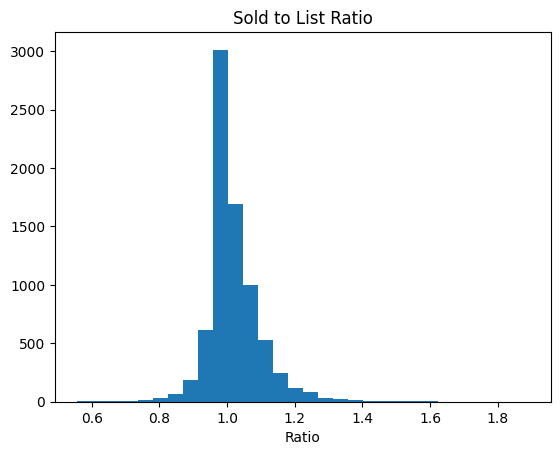

In [35]:
plt.hist(df['sold_to_list_ratio'], bins=30)
plt.title('Sold to List Ratio')
plt.xlabel('Ratio')
plt.show()

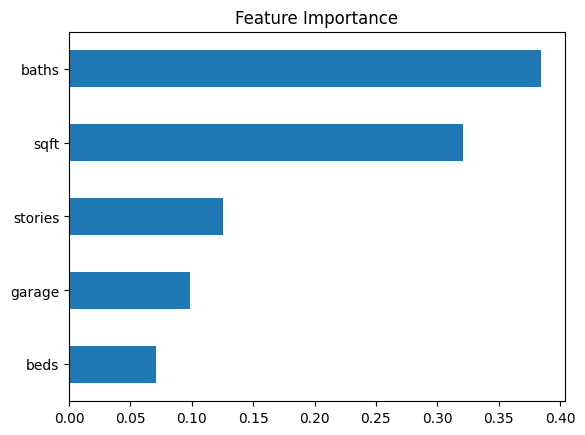

In [11]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt


X = df[['sqft','beds','baths','stories','garage']]
y = df['lastSoldPrice']

model = RandomForestRegressor(random_state=42)
model.fit(X,y)

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values()

importance.plot(kind='barh')
plt.title('Feature Importance')
plt.show()

In [13]:
important_df = importance.reset_index()
important_df.columns = ['Feature','Importance']
important_df.to_csv('feature_importance.csv', index = False)

In [14]:
important_df.head()

,Feature,Importance
0,beds,0.071150
1,garage,0.098451
2,stories,0.125099
3,sqft,0.320565
4,baths,0.384735


In [13]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Features for clustering
X = df[['sqft', 'beds', 'baths', 'garage', 'lastSoldPrice']]

# Remove missing values
X = X.dropna()

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create K-Means model (3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Fit and predict clusters
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels
X['Cluster'] = clusters

# View cluster counts
print(X['Cluster'].value_counts())

# View average characteristics of each cluster
print(X.groupby('Cluster').mean())

Cluster
2    4661
0    2567
1     480
Name: count, dtype: int64
                sqft      beds     baths    garage  lastSoldPrice
Cluster                                                          
0        2539.311005  4.023362  3.101099  1.944219   8.877401e+05
1        5662.419354  5.683042  5.091208  2.298958   2.102507e+06
2        1409.079252  2.526730  1.901607  1.229244   4.859676e+05


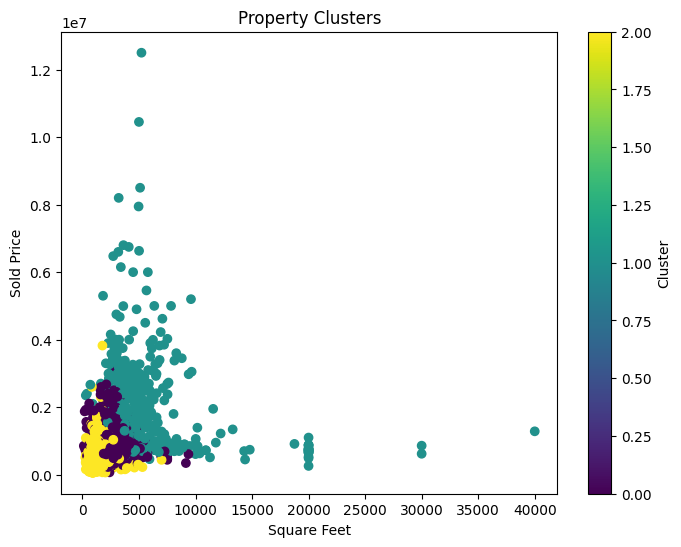

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X['sqft'],
    X['lastSoldPrice'],
    c=X['Cluster'],
    cmap='viridis'
)

plt.xlabel('Square Feet')
plt.ylabel('Sold Price')
plt.title('Property Clusters')
plt.colorbar(label='Cluster')
plt.show()

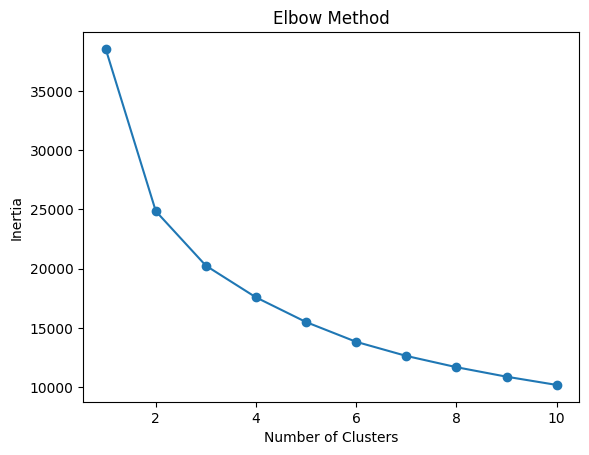

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [19]:
df.to_csv("cleaned_data.csv",index=False)

In [12]:
df

,type,text,listPrice,lastSoldPrice,sqft,stories,beds,baths,baths_full,garage,zip code,sold_to_list_ratio
0,single_family,"Welcome to [Redacted entity], a detached home ...",475000.0,504000.0,1586.00,2.00,1.0,3.0,2.0,2.00,7728.0,1.061053
1,single_family,Offer Accepted!!! No more showings! Fall in lo...,1049000.0,1125829.0,2723.32,2.00,4.0,3.0,2.0,2.00,7748.0,1.073240
2,townhomes,The Amberley model showcases a chef's dream ki...,1399000.0,1350000.0,2783.00,3.20,3.0,4.0,2.0,2.00,7059.0,0.964975
3,single_family,"JCM Development delivers once again, seamlessl...",3795000.0,3700000.0,2945.00,3.00,5.0,5.0,5.0,1.79,8202.0,0.974967
4,single_family,"This well-maintained 2-bedroom, 1-bath ranch o...",349900.0,340000.0,768.00,1.17,2.0,1.0,1.0,1.59,8251.0,0.971706
...,...,...,...,...,...,...,...,...,...,...,...,...
7703,single_family,10 Room ''EXTRAVAGANZA'' AND an in-ground pool...,699900.0,680000.0,2331.00,2.00,4.0,3.0,2.0,1.00,8753.0,0.971567
7704,single_family,"Welcome to Woodbury! This charming 3-bedroom, ...",359900.0,375000.0,1320.00,3.00,3.0,2.0,1.0,1.29,8096.0,1.041956
7705,condos,"Welcome to this luxurious two-bedroom, two-bat...",570000.0,578000.0,1018.00,1.44,2.0,2.0,2.0,1.00,7087.0,1.014035
7706,single_family,Tucked away on a quiet cul-de-sac and surround...,925000.0,900000.0,4134.57,2.15,4.0,4.0,3.0,3.00,8833.0,0.972973


In [20]:
import os 
print(os.getcwd())

C:\Users\Karan\OneDrive\Desktop\jp\.ipynb_checkpoints
